
<font size = "5"> **Day 2: [Electron Diffraction and 4D STEM](../MLSTEM2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />



[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day2/10AM_Acquire_CBED.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day2/10AM_Acquire_CBED.ipynb)


# Acquire CBED Patterns

part of the workshop of 

<font size = "5"> **[Machine Learning in Transmission Electron Microscopy](../MLSTEM2026.ipynb)**</font>


**Day1: Atomic Resolution STEM,**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**May 2026**

Main Contributer to Notebook: Utkarsh Pratish

## Import packages for figures and 
First we load the code to make figures from pyTEMlib
### Check Installed Packages



In [1]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

if test_package('pyTEMlib') < '0.2026.6.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install  --upgrade pyTEMlib -q
print('done')

done


In [6]:
%matplotlib widget
import os
import json

import matplotlib.pylab as plt
import numpy  as np

import tango
import tiled
from tiled.client import from_uri

import pyTEMlib

print('pyTEMlib version: ', pyTEMlib.__version__)


pyTEMlib version:  0.2026.6.0


## Connection to our microscope

### Ping Servers

In [7]:
DB_HOST = "10.46.217.241"
# DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")
camera = tango.DeviceProxy("asyncroscopy/camera/default")
stage = tango.DeviceProxy("asyncroscopy/stage/default")

for proxy in [scan, microscope, data, camera]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON
asyncroscopy/camera/default ON


### Conect Data Server

In [8]:
### Set Tiled Client
config = json.loads(data.get_config())
client = tiled.client.from_uri(config.get("uri"))
print("Tiled keys:", list(client))
config

Tiled keys: ['stem_image_HAADF_20260622T121457297262.h5', 'stem_image_HAADF_20260622T121515131209.h5', 'stem_image_HAADF_20260622T121718608283.h5', 'stem_image_HAADF_20260622T121811768290.h5', 'stem_image_HAADF_20260622T121846878419.h5', 'stem_image_HAADF_20260622T121906094013.h5', 'camera_image_BM-Ceta_20260622T122129622171.h5', 'stem_image_HAADF_20260622T122306394589.h5', 'stem_image_HAADF_20260622T122404037925.h5', 'stem_image_HAADF_20260622T122445781894.h5', 'stem_image_HAADF_20260622T122520552789.h5', 'stem_image_HAADF_20260622T122703330914.h5', 'stem_image_HAADF_20260622T122946694474.h5', 'stem_image_HAADF_20260622T123656869673.h5', 'camera_image_BM-Ceta_20260622T130915973468.h5', 'camera_image_BM-Ceta_20260623T100700157272.h5']


{'host': '10.46.217.241',
 'port': 9091,
 'uri': 'http://10.46.217.241:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; registered path',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

### Open column valve
If everything is okay we can open the column valve

In [9]:
microscope.set_column_valves('open')


## Acquire Convergent Beam Electron Difraction (CBED) Pattern 

In [12]:

# microscope.acquire_camera_image( 512, .1, 'flucam')
camera.exposure_time = .1
camera.imsize = 1024
camera.readout_area = 'Quarter'
data_key = microscope.acquire_camera_image()

image = client[data_key]["image"].read()
metadata = dict(client[data_key]["image"].metadata)
plt.figure()
plt.imshow(np.log(1+image))
plt.colorbar()
plt.show()
stage.alpha

DevFailed: DevFailed[
    DevError[
        desc = autoscript_core.common.ApplicationServerException: An unexpected error occurred in the application server.
            An acquisition cannot be started because the device is already used for another acquisition.
        origin = Traceback (most recent call last):
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\.venv\Lib\site-packages\tango\server.py", line 1790, in wrapped_command_method
                return get_worker().execute(cmd_method, *args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\.venv\Lib\site-packages\tango\green.py", line 110, in execute
                return fn(*args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\asyncroscopy\instruments\electron_microscope\electron_microscope.py", line 138, in acquire_camera_ima

In [ ]:
microscope.get_stage()

In [21]:
microscope.get_screen_current()

18.34610366821289

Tilt Beam

In [23]:
microscope.get_command_list()
move_alpha = -7.80
move_beta = -6.101

new_position = microscope.get_stage()
new_position[-2:] = [move_alpha, move_beta]
microscope.move_stage(new_position)


In [ ]:
move_alpha = -7.80
move_beta = -6.101

new_position = microscope.get_stage()
new_position[-2:] = [move_alpha, move_beta]
microscope.move_stage(new_position)

data_key = microscope.acquire_camera_image()
image = client[data_key]["image"].read()
metadata = dict(client[data_key]["image"].metadata)
plt.figure()
plt.imshow(image)

In [19]:
starting_position = microscope.get_stage()
starting_position[-2:] = np.degrees(starting_position[-2:])
starting_position

array([-2.1928606e-04, -3.2602172e-04,  8.3193212e-05, -7.7943263e+00,
       -6.0010705e+00], dtype=float32)

## Focus with Sample Height

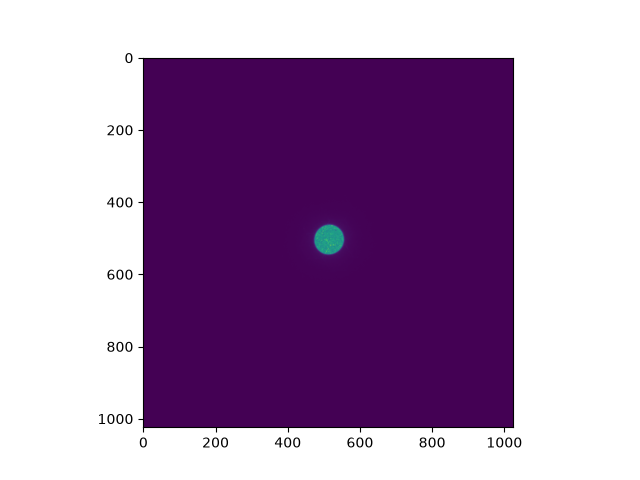

In [ ]:
move_z = -.00*1e-6

starting_position = microscope.get_stage()
starting_position[-2:] = np.degrees(starting_position[-2:])
new_position = starting_position + np.array([0, 0, move_z, 0, 0])[:len(starting_position)]
microscope.move_stage(new_position)

data_key = microscope.acquire_camera_image()
image = client[data_key]["image"].read()
metadata = dict(client[data_key]["image"].metadata)
plt.figure()
plt.imshow(image)

In [16]:
microscope.get_stage()

array([-2.19286056e-04, -3.26024747e-04,  8.31932120e-05, -1.36036664e-01,
       -1.04746915e-01], dtype=float32)

### Get Diffraction Pattern

In [16]:
### Adjust Convergence Angle

In [ ]:

image = microscope.acquisition.acquire_camera_image("Flucam", 1024, .02);
plt.figure()
plt.imshow(image.data[384:640, 384:640])



## End Session

In [72]:

microscope.vacuum.column_valves.close()
print("column valve is: ", microscope.vacuum.column_valves.state)

column valve is:  Closed


## Conclusion

Acquisition of CBED Pattern is easy.

The challenge is extracting wealth of information these pattern contain